# Task 1: Article-Type Classification

## 1. Introduction

This notebook addresses **Task 1: Article-Type Classification** for Assignment 2, where the goal is to predict the article type of a fashion product based on its RGB image, e.g. whether it is a shirt, dress or a pair of shoes. The task is formulated as a multi-class image classification problem where each image is assigned one catalog article-type label .

Three approaches using TensorFlow/Keras are developed and trained from scratch:

- **Shallow MLP (Baseline):** Fully connected with one 256-unit hidden layer on flattened image pixels.
- **Deeper MLP:** A fully connected network with 256, 128 and 64 hidden units in the layers, with dropout to prevent overfitting.
- **Convolutional Neural Network (CNN):** A spatial model which learns local image patterns via convolutional layers. The CNN family has three declared architecture/scheduling configurations.

Performance is evaluated through:

- **Accuracy:** Percentage of images correctly classified.
Macro-F1: The main selection metric, with equal weight to F1 scores of classes present in evaluation partition.
- **Classification reports and confusion matrices per class**: Evidence of which labels are well-recognized and which are confusable.
- **Learning curves:** We used training and validation loss, accuracy and macro-F1 to analyze convergence and overfitting.
**Calibration metrics:** Confidence reliability of the selected model after its selection, calculated on separate validation sets.

Categories can share silhouettes and textures. Rare categories have fewer training examples. The analysis further includes class support, common confusions and overall accuracy.

The workflow includes metadata inspection, preprocessing, model building, comparison evaluation, selection, and export for prediction All candidates work with the same frozen group isolated data partitions. A limitation is that the internal test has been exposed to previous development, even if retraining is performed. The numerical results and the final model decision have to be derived from the newly conducted results. No winner is assumed in advance.

## 2. Library Imports & Setup

Use the Fashion Keras kernel. The seed controls initialization and augmentation. Float32 is used throughout; GPU availability is reported before models are created.

In [1]:
# Locate the project, import the training libraries, select the accelerator, and fix random seeds.
from pathlib import Path
import sys, json
from concurrent.futures import ThreadPoolExecutor

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    classification_report,
    log_loss,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import GroupShuffleSplit
from scipy.optimize import minimize_scalar
import tensorflow as tf
from tensorflow import keras
from scripts.preprocessing import (
    task_frame,
    IMAGE_SIZE,
    NORMALISATION_PATH,
    SEED,
    select_tensorflow_device,
)

DEVICE = select_tensorflow_device()
keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()
OUTPUT, RESULTS, FIGURES = (ROOT / 'models', ROOT / 'results', ROOT / 'figures')
for directory in (OUTPUT, RESULTS, FIGURES):
    directory.mkdir(parents=True, exist_ok=True)
MAX_EPOCHS, BATCH_SIZE = (30, 64)

def stem_for(target):
    return 'article_type' if target == 'articleType' else target

# False for a fresh Run All. Enable only when deliberately resuming matching saved.
RESUME_SAVED_RESULTS = False

get_ipython().run_line_magic('matplotlib', 'inline')

2026-09-12 00:59:45.376883: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-12 00:59:45.418907: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-09-12 00:59:46.301008: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.20.0: /GPU:0


## 3. Load Metadata

Load valid labelled images and their frozen split assignments. Inspect paths, target labels and missing values before preprocessing.

In [2]:
# Load audited metadata and show how many labelled images are available in each frozen split.

metadata_by_target = {'articleType': task_frame('articleType')}
frame = metadata_by_target['articleType']
print('articleType', frame.shape)
display(frame.head())


articleType (38611, 15)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,productDisplayName_repaired,image_path,has_image,group_key,split
0,1163,Men,Apparel,Topwear,Tshirts,Blue,Summer,2011,Sports,Nike Sahara Team India Fanwear Round Neck Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_0,train
1,1164,Men,Apparel,Topwear,Tshirts,Blue,Winter,2015,Sports,Nike Men Blue T20 Indian Cricket Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_1,train
2,1165,Men,Apparel,Topwear,Tshirts,Blue,Summer,2013,Sports,Nike Mean Team India Cricket Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_2,train
3,1525,Unisex,Accessories,Bags,Backpacks,Navy Blue,Fall,2010,Casual,Puma Deck Navy Blue Backpack,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_3,train
4,1526,Unisex,Accessories,Bags,Backpacks,Black,Fall,2010,Sports,Puma Big Cat Backpack Black,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_4,train


## 4. Data Preprocessing

Prepare the same images and label encoding for every candidate. Preserve group isolation and fit normalization on training data only.

### 4.1. Class Distribution & Balancing

Preserve the original sample distribution. Initial candidates use unweighted cross-entropy, additional CNN experiments compare this with capped square-root inverse-frequency weights computed only from training counts. No examples are duplicated, and validation metrics remain unweighted.

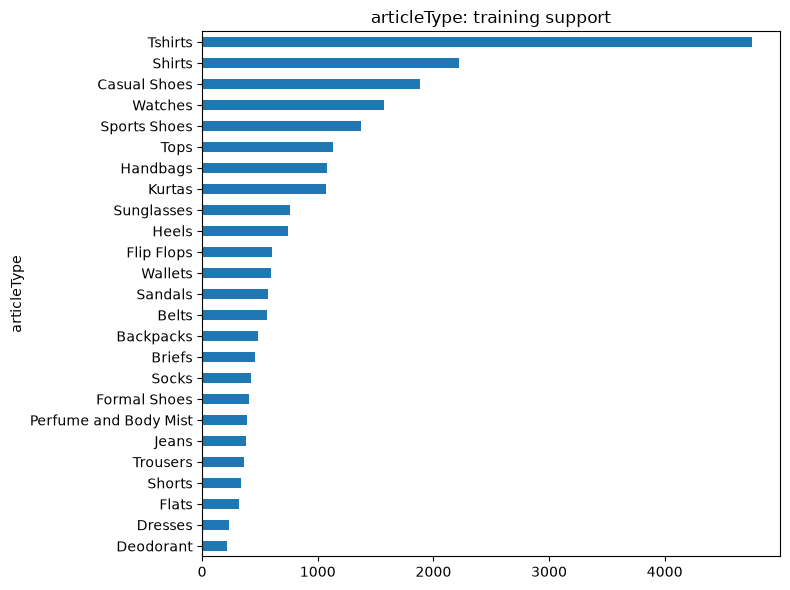

In [3]:
# Measure training-set class imbalance before choosing architectures and evaluation metrics.
train_rows = metadata_by_target['articleType'].loc[
    metadata_by_target['articleType']['split'].eq('train')
]
counts = train_rows['articleType'].value_counts()
counts.head(25).sort_values().plot.barh(figsize=(8, 6), title=f"{'articleType'}: training support")
plt.tight_layout()
plt.show()

### 4.2. Training, Validation & Test Partitions

Reuse the frozen product-group split. Within validation, use separate groups for selection, temperature fitting and policy checking.

In [4]:
# Divide validation groups into model-selection and calibration views without splitting related products.
def validation_views(frame):
    selection_ids, rest_ids = next(
        GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=SEED).split(
            frame, groups=frame.group_key
        )
    )
    selection, rest = frame.iloc[selection_ids], frame.iloc[rest_ids]
    cal_ids, policy_ids = next(
        GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=SEED + 1).split(
            rest, groups=rest.group_key
        )
    )
    return selection, rest.iloc[cal_ids], rest.iloc[policy_ids]

In [5]:
# Create the split views, fixed label order, and reusable batch loaders for each target.
frames, labels_by_target = ({}, {})
selection, calibration, policy = validation_views(
    metadata_by_target['articleType'].loc[
        metadata_by_target['articleType']['split'].eq('validation')
    ]
)
frames['articleType'] = dict(
    train=metadata_by_target['articleType'].loc[
        metadata_by_target['articleType']['split'].eq('train')
    ],
    selection=selection,
    calibration=calibration,
    policy=policy,
)
groups = [set(frame.group_key) for frame in frames['articleType'].values()]
assert all((a.isdisjoint(b) for i, a in enumerate(groups) for b in groups[i + 1 :]))
labels_by_target['articleType'] = sorted(frames['articleType']['train']['articleType'].unique())
display(
    pd.Series(
        {name: len(frame) for name, frame in frames['articleType'].items()}, name='articleType'
    )
)

train          27051
selection       2900
calibration     1378
policy          1564
Name: articleType, dtype: int64

### 4.3. Image Preprocessing

Resize RGB to 96 x 128 pixels (width x height), then normalize using training-only channel statistics. The batch class stores decoded uint8 images and converts one batch at a time to float32. Horizontal flips are applied inside each model only during training.

In [6]:
# Cache resized images in RAM and serve normalized batches to Keras during training and evaluation.
class CachedBatches(keras.utils.PyDataset):
    """Decode RGB once to uint8 RAM, then normalize each NHWC batch."""

    def __init__(self, frame, target, labels, normalisation, training=False, batch_size=64):
        super().__init__(workers=0, max_queue_size=2)
        self.dataset = frame
        self.training, self.batch_size = training, batch_size

        def read(path):
            with Image.open(path) as image:
                return np.asarray(
                    image.convert("RGB").resize(IMAGE_SIZE, Image.Resampling.BILINEAR)
                ).copy()

        # Decode and resize each source image once; later epochs reuse this cache.
        with ThreadPoolExecutor(max_workers=4) as pool:
            self.images = np.stack(list(pool.map(read, frame.image_path)))

        # Convert string labels to the fixed integer order expected by the output layer.
        self.targets = np.asarray([labels.index(label) for label in frame[target]], dtype=np.int32)
        self.mean = np.asarray(normalisation["mean"], dtype=np.float32)
        self.std = np.asarray(normalisation["std"], dtype=np.float32)
        self.reset()

    def reset(self):
        self.rng = np.random.default_rng(SEED)
        self.indices = np.arange(len(self.dataset))
        if self.training:
            self.rng.shuffle(self.indices)

    def __len__(self):
        return (len(self.dataset) + self.batch_size - 1) // self.batch_size

    # Normalize only the requested batch to avoid storing a second float32 image copy.
    def __getitem__(self, index):
        ids = self.indices[index * self.batch_size : (index + 1) * self.batch_size]
        images = self.images[ids].astype(np.float32) / 255.0
        return (images - self.mean) / self.std, self.targets[ids]

    def on_epoch_end(self):
        if self.training:
            self.rng.shuffle(self.indices)

### 4.4. Feature Batches & Label Encoding

Map sorted label names to integer indices, preserving the same order for every model. Construct shuffled training batches and fixed-order selection batches.

In [7]:
# Load normalization statistics computed from training images only, then construct all data loaders.
normalisation = json.loads(NORMALISATION_PATH.read_text())
loaders = {}
labels = labels_by_target['articleType']
loaders['articleType'] = {
    name: CachedBatches(
        frames['articleType'][name],
        'articleType',
        labels,
        normalisation,
        training=name == 'train',
        batch_size=BATCH_SIZE,
    )
    for name in ['train', 'selection']
}

## 5. Model Development & Evaluation

Train and evaluate a shallow MLP baseline, a deeper MLP and a CNN using the same image preprocessing and frozen partitions. Architecture construction, fitting, class-level evaluation, calibration and model export are implemented in this notebook.

### Evaluation Metric: Macro-F1

Accumulate the full-epoch confusion matrix and average F1 over classes with positive ground-truth support. This metric selects the restored epoch and winning model. It does not average per-batch F1 scores.

The displayed per-class classification report also includes every output label for coverage auditing. Its standard `macro avg` row therefore includes zero-support output labels and can differ from the supported-class macro-F1 used for selection. Read the explicitly reported selection metric for model ranking, and inspect support before making claims about all classes. Selection support is 97/124 article types, 4/4 seasons, 5/5 gender categories and 8/9 occasion labels for this frozen run.

In [8]:
# Track macro-F1 across a complete epoch with a running confusion matrix.
@keras.utils.register_keras_serializable(package="Fashion")
class SupportedMacroF1(keras.metrics.Metric):
    """Macro-F1 over classes present in the full epoch's ground truth."""

    def __init__(self, num_classes, name="macro_f1", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.matrix = self.add_weight(
            name="matrix", shape=(num_classes, num_classes), initializer="zeros"
        )

    # Accumulate one confusion matrix across all batches in the epoch.
    def update_state(self, y_true, y_pred, sample_weight=None):
        truth = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        predictions = tf.argmax(y_pred, axis=-1, output_type=tf.int32)
        weights = (
            None if sample_weight is None else tf.cast(tf.reshape(sample_weight, [-1]), self.dtype)
        )
        self.matrix.assign_add(
            tf.math.confusion_matrix(
                truth, predictions, self.num_classes, weights=weights, dtype=self.dtype
            )
        )

    # Average F1 only across classes that are present in the ground truth.
    def result(self):
        support = tf.reduce_sum(self.matrix, axis=1)
        predicted = tf.reduce_sum(self.matrix, axis=0)
        f1 = tf.math.divide_no_nan(2 * tf.linalg.diag_part(self.matrix), support + predicted)
        mask = tf.cast(support > 0, self.dtype)
        return tf.math.divide_no_nan(tf.reduce_sum(f1 * mask), tf.reduce_sum(mask))

    def reset_state(self):
        self.matrix.assign(tf.zeros_like(self.matrix))

    def get_config(self):
        return {**super().get_config(), "num_classes": self.num_classes}

### Saved-Model Metadata

An identity layer stores label order, preprocessing and confidence policy inside each exported Keras model.

In [9]:
# Attach labels and preprocessing settings to the exported Keras model as a pass-through layer.
@keras.utils.register_keras_serializable(package="Fashion")
class ModelMetadata(keras.layers.Layer):
    """Store label order, preprocessing and calibration inside the .keras file."""

    def __init__(self, metadata=None, **kwargs):
        super().__init__(**kwargs)
        self.metadata = dict(metadata or {})

    def call(self, inputs):
        return inputs

    def get_config(self):
        return {**super().get_config(), "metadata": dict(self.metadata)}

In [10]:
# Keep trained models, learning histories, and selection scores organized by target and method.
models = {'articleType': {}}
histories = {'articleType': {}}
selection_scores = {}

### General design justification

We fix a 96x128 RGB input size that allows batching and inference consistency while keeping computation manageable. Its portrait aspect ratio is the one that dominates in the 60x80 format. We do not assume that larger inputs will improve recognition, since resizing cannot recover missing details. The output units correspond to the label vocabulary of the target, they are not a free tuned capacity parameter.

A naive pixel-based baseline is obtained by flattening. A shallow MLP tests whether one nonlinear hidden layer is enough and a deeper MLP tests additional nonlinear transformations. Dense layers do not explicitly preserve local spatial relations and flattening leads to huge parameter counts. ReLU non-linearity. Hidden widths and depths are chosen according to validation evidence, not just the number of classes.

Small convolutions of size 3x3 share weights over spatial locations and can learn local appearance patterns. Larger image areas can be formed by combining successive blocks. Max pooling reduces spatial dimensions and computational cost, but can throw away fine detail . The last 2x2 average-pooled grid restricts the size of the dense head, but preserves the coarse spatial layout. "Batch normalization" stabilizes the scale of intermediate activations. These design properties are an inspiration for CNN use, but they do not establish that a learned filter detects a specific garment feature.

Dropout 0.2 prevents reliance on individual hidden activations and training-only horizontal flips present models with mirrored product views. These are attempts to improve generalization, not promises. Adam adapts parameter updates; reducing its learning rate on a validation plateau allows for smaller updates later in CNN training. If there is no improvement, early stopping stops training and returns the best macro-F1 epoch selection. The fixed seed makes it repeatable and batch size 64 is a more practical training setting than the claimed optimum.

Group-isolated partitions prevent related-product leakage, training-only normalization prevents fitting preprocessing to evaluation data, and macro-F1 balances each supported class equally. Accuracy, class-level errors and parameter counts give complementary evidence. The specific choices were justified by the measured validation comparison, the general principles above explain their intended roles, with different labels favoring different capacities.


In [11]:
SELECTED_CONFIGS = {
    'articleType': {
        'shallow_mlp': {
            'method': 'shallow_mlp_lower_lr',
            'widths': [256],
            'learning_rate': 0.0001,
            'epochs': 20,
            'patience': 4,
        },
        'deeper_mlp': {
            'method': 'deeper_mlp_two_layers',
            'widths': [256, 128],
            'learning_rate': 0.0003,
            'epochs': 20,
            'patience': 4,
        },
        'cnn': {
            'method': 'cnn_continue_weighted',
            'widths': [256],
            'learning_rate': 3e-05,
            'epochs': 30,
            'patience': 7,
        },
    }
}

### 5.1. Shallow MLP (Baseline)

Flattened RGB input is passed through the selected dense layers, with ReLU and dropout 0.2 after each hidden layer.

#### 5.1.1. Article Type: Model Architecture & Training Configuration

Configuration `shallow_mlp_lower_lr`; hidden dense units [256]. Adam 0.0001, maximum 20 epochs, early-stopping patience 4.

In [12]:
# Build the shallow MLP from the selected target-specific configuration.
config = SELECTED_CONFIGS['articleType']['shallow_mlp']
method = config['method']
keras.utils.set_random_seed(SEED)

# Start with a fixed image input and training-only horizontal augmentation.
layers = [
    keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)),
    keras.layers.RandomFlip('horizontal'),
]
layers.append(keras.layers.Flatten())

# Add the configured hidden classifier layers and dropout regularization.
for width in config['widths']:
    layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
layers.extend(
    [keras.layers.Dense(len(labels_by_target['articleType'])), ModelMetadata(name='metadata')]
)
models['articleType'][method] = keras.Sequential(layers, name=method)
models['articleType'][method].summary()

I0000 00:00:1789149647.907785   33876 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9709 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "shallow_mlp_lower_lr"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 124)            │        31,868 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ metadata (ModelMetadata)        │ (None, 124)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,469,308 (36.12 MB)

 Trainable params: 9,469,308 (36.12 MB)

 Non-trainable params: 0 (0.00 B)

#### 5.1.2. Compile & Train Model

The selection view controls epoch selection. Test images are excluded from training.

In [13]:
# Compile and train the model while restoring the epoch with the best selection macro-F1.
model = models['articleType'][method]

# Configure optimization and report both accuracy and imbalance-aware macro-F1.
model.compile(
    optimizer=keras.optimizers.Adam(0.0001),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
        SupportedMacroF1(len(labels_by_target['articleType'])),
    ],
)
loaders['articleType']['train'].reset()

# Stop when selection macro-F1 no longer improves and restore its best weights.
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_macro_f1', mode='max', patience=4, restore_best_weights=True
    )
]

# Keep the selection partition read-only: it chooses epochs but never updates weights.
fitted = model.fit(
    loaders['articleType']['train'],
    validation_data=loaders['articleType']['selection'],
    epochs=20,
    callbacks=callbacks,
    shuffle=False,
    verbose=2,
)
histories['articleType'][method] = pd.DataFrame(fitted.history)

Epoch 1/20


423/423 - 13s - 31ms/step - accuracy: 0.5507 - loss: 1.8796 - macro_f1: 0.1490 - val_accuracy: 0.6455 - val_loss: 1.4375 - val_macro_f1: 0.2277


Epoch 2/20


423/423 - 11s - 26ms/step - accuracy: 0.6427 - loss: 1.3946 - macro_f1: 0.2097 - val_accuracy: 0.6662 - val_loss: 1.2696 - val_macro_f1: 0.2343


Epoch 3/20


...

423/423 - 11s - 26ms/step - accuracy: 0.7685 - loss: 0.7728 - macro_f1: 0.4482 - val_accuracy: 0.7445 - val_loss: 1.0476 - val_macro_f1: 0.4208


Epoch 14/20


423/423 - 11s - 26ms/step - accuracy: 0.7719 - loss: 0.7698 - macro_f1: 0.4519 - val_accuracy: 0.7524 - val_loss: 0.9677 - val_macro_f1: 0.4109


Epoch 15/20


423/423 - 11s - 26ms/step - accuracy: 0.7801 - loss: 0.7116 - macro_f1: 0.4754 - val_accuracy: 0.7579 - val_loss: 0.9965 - val_macro_f1: 0.4368


#### 5.1.3. Evaluation and Performance Metrics

Calculate validation accuracy and supported-class macro-F1, display the per-class classification report, and plot training and validation loss, accuracy and macro-F1. These measurements use the restored best epoch.

selection_accuracy    0.742069
selection_macro_f1    0.443202
dtype: float64

,precision,recall,f1-score,support
Accessory Gift Set,1.000000,0.833333,0.909091,12.000000
Baby Dolls,0.000000,0.000000,0.000000,0.000000
Backpacks,0.833333,0.925926,0.877193,54.000000
Bangle,1.000000,0.076923,0.142857,13.000000
Basketballs,1.000000,0.333333,0.500000,3.000000
...,...,...,...,...
Water Bottle,0.000000,0.000000,0.000000,1.000000
Wristbands,0.000000,0.000000,0.000000,0.000000
accuracy,0.742069,0.742069,0.742069,0.742069
macro avg,0.401361,0.344125,0.346698,2900.000000


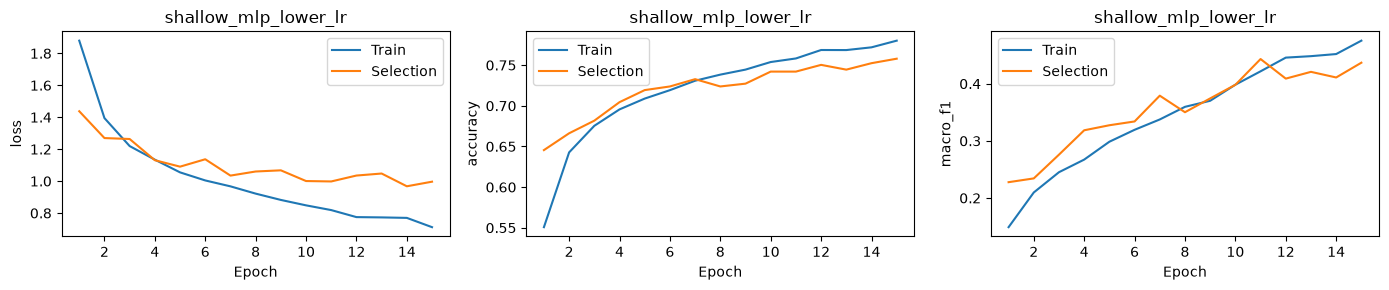

In [14]:
# Evaluate the restored best weights, show class metrics, and plot the learning curves.
loader = loaders['articleType']['selection']

# Convert logits to probabilities and preserve the loader's row order.
probabilities = np.vstack(
    [
        tf.nn.softmax(models['articleType'][method](loader[i][0], training=False)).numpy()
        for i in range(len(loader))
    ]
)
predictions = probabilities.argmax(1)
display(
    pd.Series(
        dict(
            selection_accuracy=accuracy_score(loader.targets, predictions),
            selection_macro_f1=f1_score(
                loader.targets,
                predictions,
                labels=np.unique(loader.targets),
                average='macro',
                zero_division=0,
            ),
        )
    )
)

# Inspect every label because aggregate accuracy can hide minority-class failures.
per_class = pd.DataFrame(
    classification_report(
        loader.targets,
        predictions,
        labels=np.arange(len(labels_by_target['articleType'])),
        target_names=labels_by_target['articleType'],
        output_dict=True,
        zero_division=0,
    )
).T
display(per_class)
per_class.to_csv(RESULTS / f"{stem_for('articleType')}_{method}_selection_per_class.csv")

# Plot train and selection curves to diagnose convergence and overfitting.
history = histories['articleType'][method]
history.to_csv(RESULTS / f"{stem_for('articleType')}_{method}_history.csv", index=False)
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
    ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
    ax.plot(np.arange(1, len(history) + 1), history['val_' + metric], label='Selection')
    ax.set(xlabel='Epoch', ylabel=metric, title=method)
    ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / f"{stem_for('articleType')}_{method}_learning_curves.png", dpi=160)
plt.show()

# Store one comparable row for the final cross-family decision.
selection_scores.setdefault('articleType', {})[method] = dict(
    family='shallow_mlp',
    validation_accuracy=accuracy_score(loader.targets, predictions),
    validation_macro_f1=f1_score(
        loader.targets,
        predictions,
        labels=np.unique(loader.targets),
        average='macro',
        zero_division=0,
    ),
    complexity_parameters=models['articleType'][method].count_params(),
    epochs_run=len(history),
)

#### 5.1.4. Evaluation Analysis

The Shallow MLP had 74.21% selection accuracy and 0.4432 supported-class macro-F1 with 9,469,308 parameters. The best macro-F1 epoch was 11 out of 15 in the training run. The training accuracy of the model was 75.82% at that epoch, with a training loss of 0.8186 and a selection loss of 0.9979. The small accuracy gap gives little evidence of severe overfitting. Dropout and augmentation only in training create different evaluation conditions.

Tshirts precision 0.816, recall 0.895 and F1 0.854 (n=512); Shirts precision 0.731, recall 0.831 and F1 0.778 (n=213); Watches precision 0.963, recall 0.972 and F1 0.967 (n=213); Bangle precision 1.000, recall 0.077 and F1 0.143 (n=13); Capris precision 0.222, recall 0.143 and F1 0.174 (n=14). of 97 represented classes, 28 have no recall. Supported-class macro-F1 does not include classes that are missing in this partition. 

The dense model can be compared to flattened pixels but it does not outperform the CNN on selection macro-F1. Additional depth does not, in itself, mean better generalization. These results characterize this completed run; broader claims are constrained by minority support and a single random seed.

### 5.2. Deeper MLP

Flattened RGB input is passed through the selected dense layers, with ReLU and dropout 0.2 after each hidden layer.

#### 5.2.1. Article Type: Model Architecture & Training Configuration

Configuration `deeper_mlp_two_layers`; hidden dense units [256, 128]. Adam 0.0003, maximum 20 epochs, early-stopping patience 4.

In [15]:
# Build the deeper MLP from the selected target-specific configuration.
config = SELECTED_CONFIGS['articleType']['deeper_mlp']
method = config['method']
keras.utils.set_random_seed(SEED)

# Start with a fixed image input and training-only horizontal augmentation.
layers = [
    keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)),
    keras.layers.RandomFlip('horizontal'),
]
layers.append(keras.layers.Flatten())

# Add the configured hidden classifier layers and dropout regularization.
for width in config['widths']:
    layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
layers.extend(
    [keras.layers.Dense(len(labels_by_target['articleType'])), ModelMetadata(name='metadata')]
)
models['articleType'][method] = keras.Sequential(layers, name=method)
models['articleType'][method].summary()

Model: "deeper_mlp_two_layers"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 124)            │        15,996 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ metadata (ModelMetadata)        │ (None, 124)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,486,332 (36.19 MB)

 Trainable params: 9,486,332 (36.19 MB)

 Non-trainable params: 0 (0.00 B)

#### 5.2.2. Compile & Train Model

The selection view controls epoch selection. Test images are excluded from training.

In [16]:
# Compile and train the model while restoring the epoch with the best selection macro-F1.
model = models['articleType'][method]

# Configure optimization and report both accuracy and imbalance-aware macro-F1.
model.compile(
    optimizer=keras.optimizers.Adam(0.0003),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
        SupportedMacroF1(len(labels_by_target['articleType'])),
    ],
)
loaders['articleType']['train'].reset()

# Stop when selection macro-F1 no longer improves and restore its best weights.
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_macro_f1', mode='max', patience=4, restore_best_weights=True
    )
]

# Keep the selection partition read-only: it chooses epochs but never updates weights.
fitted = model.fit(
    loaders['articleType']['train'],
    validation_data=loaders['articleType']['selection'],
    epochs=20,
    callbacks=callbacks,
    shuffle=False,
    verbose=2,
)
histories['articleType'][method] = pd.DataFrame(fitted.history)

Epoch 1/20


423/423 - 12s - 28ms/step - accuracy: 0.4444 - loss: 2.4194 - macro_f1: 0.0965 - val_accuracy: 0.6069 - val_loss: 1.6807 - val_macro_f1: 0.1792


Epoch 2/20


423/423 - 11s - 26ms/step - accuracy: 0.5556 - loss: 1.7662 - macro_f1: 0.1429 - val_accuracy: 0.6266 - val_loss: 1.4277 - val_macro_f1: 0.1940


Epoch 3/20


...

423/423 - 11s - 27ms/step - accuracy: 0.7178 - loss: 0.9304 - macro_f1: 0.3184 - val_accuracy: 0.7300 - val_loss: 0.9476 - val_macro_f1: 0.3628


Epoch 19/20


423/423 - 11s - 27ms/step - accuracy: 0.7233 - loss: 0.9056 - macro_f1: 0.3265 - val_accuracy: 0.7179 - val_loss: 0.9428 - val_macro_f1: 0.3544


Epoch 20/20


423/423 - 11s - 27ms/step - accuracy: 0.7245 - loss: 0.9158 - macro_f1: 0.3383 - val_accuracy: 0.7324 - val_loss: 0.9279 - val_macro_f1: 0.3783


#### 5.2.3. Evaluation and Performance Metrics

Calculate validation accuracy and supported-class macro-F1, display the per-class classification report, and plot training and validation loss, accuracy and macro-F1. These measurements use the restored best epoch.

selection_accuracy    0.732414
selection_macro_f1    0.378301
dtype: float64

,precision,recall,f1-score,support
Accessory Gift Set,0.909091,0.833333,0.869565,12.000000
Baby Dolls,0.000000,0.000000,0.000000,0.000000
Backpacks,0.775862,0.833333,0.803571,54.000000
Bangle,0.666667,0.307692,0.421053,13.000000
Basketballs,0.000000,0.000000,0.000000,3.000000
...,...,...,...,...
Water Bottle,0.000000,0.000000,0.000000,1.000000
Wristbands,0.000000,0.000000,0.000000,0.000000
accuracy,0.732414,0.732414,0.732414,0.732414
macro avg,0.323274,0.302526,0.295929,2900.000000


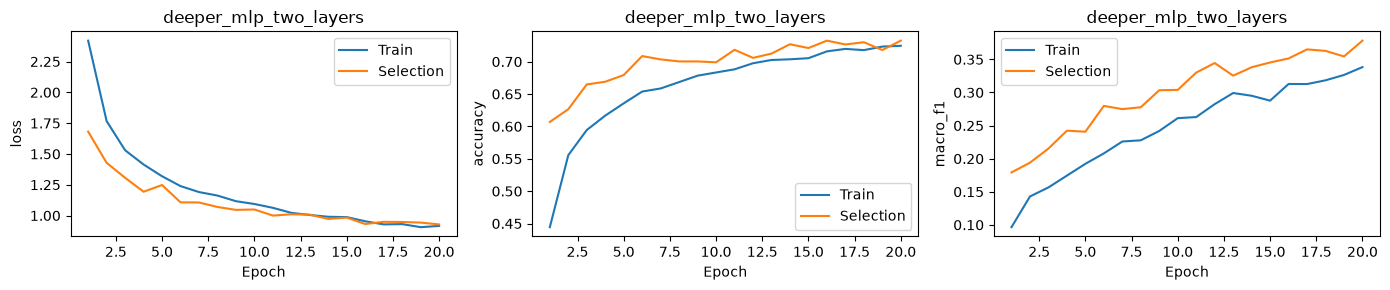

In [17]:
# Evaluate the restored best weights, show class metrics, and plot the learning curves.
loader = loaders['articleType']['selection']

# Convert logits to probabilities and preserve the loader's row order.
probabilities = np.vstack(
    [
        tf.nn.softmax(models['articleType'][method](loader[i][0], training=False)).numpy()
        for i in range(len(loader))
    ]
)
predictions = probabilities.argmax(1)
display(
    pd.Series(
        dict(
            selection_accuracy=accuracy_score(loader.targets, predictions),
            selection_macro_f1=f1_score(
                loader.targets,
                predictions,
                labels=np.unique(loader.targets),
                average='macro',
                zero_division=0,
            ),
        )
    )
)

# Inspect every label because aggregate accuracy can hide minority-class failures.
per_class = pd.DataFrame(
    classification_report(
        loader.targets,
        predictions,
        labels=np.arange(len(labels_by_target['articleType'])),
        target_names=labels_by_target['articleType'],
        output_dict=True,
        zero_division=0,
    )
).T
display(per_class)
per_class.to_csv(RESULTS / f"{stem_for('articleType')}_{method}_selection_per_class.csv")

# Plot train and selection curves to diagnose convergence and overfitting.
history = histories['articleType'][method]
history.to_csv(RESULTS / f"{stem_for('articleType')}_{method}_history.csv", index=False)
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
    ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
    ax.plot(np.arange(1, len(history) + 1), history['val_' + metric], label='Selection')
    ax.set(xlabel='Epoch', ylabel=metric, title=method)
    ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / f"{stem_for('articleType')}_{method}_learning_curves.png", dpi=160)
plt.show()

# Store one comparable row for the final cross-family decision.
selection_scores.setdefault('articleType', {})[method] = dict(
    family='deeper_mlp',
    validation_accuracy=accuracy_score(loader.targets, predictions),
    validation_macro_f1=f1_score(
        loader.targets,
        predictions,
        labels=np.unique(loader.targets),
        average='macro',
        zero_division=0,
    ),
    complexity_parameters=models['articleType'][method].count_params(),
    epochs_run=len(history),
)

#### 5.2.4. Evaluation Analysis

The Deeper MLP achieved 73.24% selection accuracy and 0.3783 supported-class macro-F1 with 9,486,332 parameters**. The best macro-F1 epoch was 20 out of 20 in the training run. At that epoch, the model achieved 72.45% accuracy in training, 0.9158 in training loss, and 0.9279 in selection loss. The small gap in accuracy is hardly an evidence of severe over-fitting. The two evaluation conditions are different due to dropout and augmentation only in training.

Tshirts has precision 0.850, recall 0.865 and F1 0.858 (n=512); Shirts has precision 0.774, recall 0.850 and F1 0.810 (n=213); Watches has precision 0.941, recall 0.977 and F1 0.959 (n=213); Bangle has precision 0.667, recall 0.308 and F1 0.421 (n=13); Capris has precision 0.167, recall 0.071 and F1 0.100 (n=14). 38 out of 97 represented classes have zero recall. Classes not present in this partition are not included in supported-class macro-F1. 

The dense model can be compared to flattened pixels but it does not outperform the CNN on selection macro-F1. Additional depth does not, in itself, mean better generalization. These results characterize this completed run; broader claims are constrained by minority support and a single random seed.

### 5.3. Convolutional Neural Network (CNN)

The selected CNN uses four 3 x 3 convolution blocks (32, 64, 128, 256 filters), batch normalization, ReLU and max pooling, followed by a 2 x 2 pooled grid and Dense(256). Only the selected continuation, when required, is fitted.

#### 5.3.1. Article Type: Model Architecture & Training Configuration

Configuration `cnn_continue_weighted`; hidden dense units [256]. Initial Adam 0.001, maximum 30 epochs, early-stopping patience 7 and learning-rate halving after two unimproved epochs. Continuation, if specified, uses eight additional epochs with patience 4 and a fresh optimizer.

In [18]:
# Build the CNN from the selected target-specific configuration.
config = SELECTED_CONFIGS['articleType']['cnn']
method = config['method']
keras.utils.set_random_seed(SEED)

# Start with a fixed image input and training-only horizontal augmentation.
layers = [
    keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)),
    keras.layers.RandomFlip('horizontal'),
]

# Learn increasingly abstract local features while reducing spatial resolution.
for width in [32, 64, 128, 256]:
    layers.extend(
        [
            keras.layers.Conv2D(width, 3, padding='same'),
            keras.layers.BatchNormalization(),
            keras.layers.Activation('relu'),
            keras.layers.MaxPooling2D(2),
        ]
    )
h, w = IMAGE_SIZE[1] // 16, IMAGE_SIZE[0] // 16
layers.extend([keras.layers.AveragePooling2D((h // 2, w // 2)), keras.layers.Flatten()])

# Add the configured hidden classifier layers and dropout regularization.
for width in config['widths']:
    layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
layers.extend(
    [keras.layers.Dense(len(labels_by_target['articleType'])), ModelMetadata(name='metadata')]
)
models['articleType'][method] = keras.Sequential(layers, name=method)
models['articleType'][method].summary()

Model: "cnn_continue_weighted"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)      │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 96, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 96, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 96, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 2, 2, 256)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 124)            │        31,868 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 684,604 (2.61 MB)

 Trainable params: 683,644 (2.61 MB)

 Non-trainable params: 960 (3.75 KB)

#### 5.3.2. Compile & Train Model

The selection view controls epoch selection. Test images are excluded from training.

In [19]:
# Compile and train the model while restoring the epoch with the best selection macro-F1.
model = models['articleType'][method]

# Configure optimization and report both accuracy and imbalance-aware macro-F1.
model.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
        SupportedMacroF1(len(labels_by_target['articleType'])),
    ],
)
loaders['articleType']['train'].reset()

# Stop when selection macro-F1 no longer improves and restore its best weights.
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_macro_f1', mode='max', patience=7, restore_best_weights=True
    )
]
callbacks.insert(
    0, keras.callbacks.ReduceLROnPlateau(monitor='val_macro_f1', mode='max', factor=0.5, patience=2)
)

# Keep the selection partition read-only: it chooses epochs but never updates weights.
fitted = model.fit(
    loaders['articleType']['train'],
    validation_data=loaders['articleType']['selection'],
    epochs=30,
    callbacks=callbacks,
    shuffle=False,
    verbose=2,
)
histories['articleType'][method] = pd.DataFrame(fitted.history)
histories['articleType'][method].to_csv(
    RESULTS / 'article_type_cnn_initial_history.csv', index=False
)

# Begin the low-learning-rate continuation from the initial CNN weights.
# Reset the loader so continuation starts from a reproducible order.
keras.utils.set_random_seed(SEED)
loaders['articleType']['train'].reset()
model.compile(
    optimizer=keras.optimizers.Adam(3e-05),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
        SupportedMacroF1(len(labels_by_target['articleType'])),
    ],
)
class_weight = None

# Use capped square-root class weights to help rare labels without destabilizing training.
counts = np.bincount(
    loaders['articleType']['train'].targets, minlength=len(labels_by_target['articleType'])
)
weights = np.sqrt(counts.sum() / (len(counts) * counts))
weights = np.clip(weights / np.average(weights, weights=counts), 0.25, 4)
class_weight = dict(enumerate(weights))
fitted = model.fit(
    loaders['articleType']['train'],
    validation_data=loaders['articleType']['selection'],
    epochs=8,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_macro_f1', mode='max', patience=4, restore_best_weights=True
        )
    ],
    class_weight=class_weight,
    shuffle=False,
    verbose=2,
)
histories['articleType'][method] = pd.DataFrame(fitted.history)

Epoch 1/30


2026-09-12 01:07:22.817532: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92501


423/423 - 29s - 68ms/step - accuracy: 0.5627 - loss: 1.7041 - macro_f1: 0.1335 - val_accuracy: 0.5534 - val_loss: 1.6694 - val_macro_f1: 0.1755 - learning_rate: 0.0010


Epoch 2/30


423/423 - 26s - 62ms/step - accuracy: 0.7107 - loss: 1.0032 - macro_f1: 0.2346 - val_accuracy: 0.7124 - val_loss: 0.9867 - val_macro_f1: 0.2925 - learning_rate: 0.0010


...

423/423 - 26s - 62ms/step - accuracy: 0.9643 - loss: 0.1378 - macro_f1: 0.9235 - val_accuracy: 0.8697 - val_loss: 0.5339 - val_macro_f1: 0.6964


Epoch 7/8


423/423 - 26s - 63ms/step - accuracy: 0.9643 - loss: 0.1330 - macro_f1: 0.9178 - val_accuracy: 0.8703 - val_loss: 0.5411 - val_macro_f1: 0.6758


Epoch 8/8


423/423 - 26s - 62ms/step - accuracy: 0.9627 - loss: 0.1357 - macro_f1: 0.9257 - val_accuracy: 0.8710 - val_loss: 0.5367 - val_macro_f1: 0.6837


#### 5.3.3. Evaluation and Performance Metrics

Calculate validation accuracy and supported-class macro-F1, display the per-class classification report, and plot training and validation loss, accuracy and macro-F1. These measurements use the restored best epoch.

selection_accuracy    0.869655
selection_macro_f1    0.696432
dtype: float64

,precision,recall,f1-score,support
Accessory Gift Set,1.000000,1.000000,1.000000,12.000000
Baby Dolls,0.000000,0.000000,0.000000,0.000000
Backpacks,0.961538,0.925926,0.943396,54.000000
Bangle,0.500000,0.153846,0.235294,13.000000
Basketballs,1.000000,1.000000,1.000000,3.000000
...,...,...,...,...
Water Bottle,1.000000,1.000000,1.000000,1.000000
Wristbands,0.000000,0.000000,0.000000,0.000000
accuracy,0.869655,0.869655,0.869655,0.869655
macro avg,0.550852,0.560549,0.544790,2900.000000


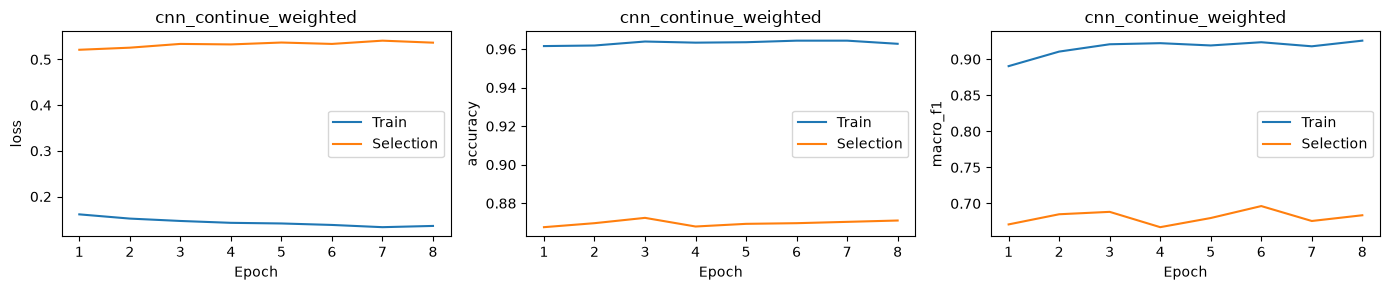

In [20]:
# Evaluate the restored best weights, show class metrics, and plot the learning curves.
loader = loaders['articleType']['selection']

# Convert logits to probabilities and preserve the loader's row order.
probabilities = np.vstack(
    [
        tf.nn.softmax(models['articleType'][method](loader[i][0], training=False)).numpy()
        for i in range(len(loader))
    ]
)
predictions = probabilities.argmax(1)
display(
    pd.Series(
        dict(
            selection_accuracy=accuracy_score(loader.targets, predictions),
            selection_macro_f1=f1_score(
                loader.targets,
                predictions,
                labels=np.unique(loader.targets),
                average='macro',
                zero_division=0,
            ),
        )
    )
)

# Inspect every label because aggregate accuracy can hide minority-class failures.
per_class = pd.DataFrame(
    classification_report(
        loader.targets,
        predictions,
        labels=np.arange(len(labels_by_target['articleType'])),
        target_names=labels_by_target['articleType'],
        output_dict=True,
        zero_division=0,
    )
).T
display(per_class)
per_class.to_csv(RESULTS / f"{stem_for('articleType')}_{method}_selection_per_class.csv")

# Plot train and selection curves to diagnose convergence and overfitting.
history = histories['articleType'][method]
history.to_csv(RESULTS / f"{stem_for('articleType')}_{method}_history.csv", index=False)
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
    ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
    ax.plot(np.arange(1, len(history) + 1), history['val_' + metric], label='Selection')
    ax.set(xlabel='Epoch', ylabel=metric, title=method)
    ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / f"{stem_for('articleType')}_{method}_learning_curves.png", dpi=160)
plt.show()

# Store one comparable row for the final cross-family decision.
selection_scores.setdefault('articleType', {})[method] = dict(
    family='cnn',
    validation_accuracy=accuracy_score(loader.targets, predictions),
    validation_macro_f1=f1_score(
        loader.targets,
        predictions,
        labels=np.unique(loader.targets),
        average='macro',
        zero_division=0,
    ),
    complexity_parameters=models['articleType'][method].count_params(),
    epochs_run=len(history),
)

#### 5.3.4. Evaluation Analysis

The CNN achieved 86.97% selection accuracy and 0.6964 supported-class macro-F1 with 684,604 parameters. The best macro-F1 epoch of the continuation stage was 6 of 8. The model at this point has a training accuracy of 96.43%, training loss of 0.1378, and selection loss of 0.5339. The discrepancy between accuracies indicates some over-fitting, the restored checkpoint is selected by the selection performance but not the training accuracy. The class-weighted training loss is not directly comparable to the unweighted selection loss.

Tshirts precision 0.947, recall 0.938 and F1 0.942 (n=512); Shirts precision 0.909, recall 0.934 and F1 0.921 (n=213); Watches precision 0.986, recall 0.962 and F1 0.974 (n=213); Bangle precision 0.500, recall 0.154 and F1 0.235 (n=13); Capris precision 0.625, recall 0.357 and F1 0.455 (n=14). 13 out of 97 represented classes with zero recall. Supported-class macro-F1 does not include classes outside this partition. 

This CNN wins the declared selection rule, and is exported as the final classifier. Convolution preserves the local image relationships, and provides a more efficient representation than the flattened dense models. These results characterize this completed run, minority support and a single random seed constrain broader claims.

## 6. Ultimate Judgement

The three model families are compared using the validation metrics already calculated in their evaluation sections. The model with the highest validation macro-F1 is selected. Accuracy and parameter count are used to interpret the result and would break an exact macro-F1 tie.

In [21]:
# Prepare containers for the cross-family comparison and final checkpoints.
comparisons, winners, checkpoints = {}, {}, {}

In [22]:
# Rank the three model families by macro-F1, then accuracy, then parameter count.
comparison = pd.DataFrame(selection_scores['articleType']).T
comparison = comparison.sort_values(
    ['validation_macro_f1', 'validation_accuracy', 'complexity_parameters'],
    ascending=[False, False, True],
)
winners['articleType'] = comparison.index[0]
comparison['selected'] = comparison.index == winners['articleType']
comparisons['articleType'] = comparison
display(comparison)
print('Selected:', winners['articleType'])
comparison.to_csv(RESULTS / 'article_type_comparison.csv')

,family,validation_accuracy,validation_macro_f1,complexity_parameters,epochs_run,selected
cnn_continue_weighted,cnn,0.869655,0.696432,684604,8,True
shallow_mlp_lower_lr,shallow_mlp,0.742069,0.443202,9469308,15,False
deeper_mlp_two_layers,deeper_mlp,0.732414,0.378301,9486332,20,False


Selected: cnn_continue_weighted


**Model comparison: articleType**

| Family | Configuration | Selection accuracy | Macro-F1 | Parameters |
|---|---|---:|---:|---:|
| Shallow MLP | shallow_mlp_lower_lr | 74.21% | 0.4432 | 9,469,308 |
| Deeper MLP | deeper_mlp_two_layers | 73.24% | 0.3783 | 9,486,332 |
| CNN | cnn_continue_weighted | 86.97% | 0.6964 | 684,604 |


In [23]:
# Define imbalance-aware performance and probability-calibration metrics for the final test.
def supported_macro_f1(truth, predictions) -> float:
    """Macro-average over labels present in the ground-truth partition."""
    return float(
        f1_score(truth, predictions, labels=np.unique(truth), average="macro", zero_division=0)
    )


def expected_calibration_error(
    truth: np.ndarray,
    probabilities: np.ndarray,
    bins: int = 10,
) -> float:
    """Compute top-label expected calibration error."""
    truth = np.asarray(truth)
    probabilities = np.asarray(probabilities)
    confidence = probabilities.max(axis=1)
    correct = probabilities.argmax(axis=1) == truth
    edges = np.linspace(0.0, 1.0, bins + 1)
    total = len(truth)
    error = 0.0
    for lower, upper in zip(edges[:-1], edges[1:], strict=True):
        selected = (confidence > lower) & (confidence <= upper)
        if selected.any():
            error += (
                selected.sum()
                / total
                * abs(float(correct[selected].mean()) - float(confidence[selected].mean()))
            )
    return float(error)

### 6.1. Selected-Model Evaluation

Evaluate only the selected model on the internal test partition. This cell reports accuracy, supported-class macro-F1, calibration error, negative log-likelihood, Brier score and a per-class classification report. The internal test has prior development exposure and is not used to revise the selected architecture.

In [24]:
# Evaluate each selected family winner once on the untouched internal-test partition.
test_results = {}
checkpoints = {}

method = winners['articleType']
model = models['articleType'][method]
test_frame = metadata_by_target['articleType'].loc[
    metadata_by_target['articleType']['split'].eq('test')
]
test_loader = CachedBatches(
    test_frame, 'articleType', labels_by_target['articleType'], normalisation, batch_size=BATCH_SIZE
)

# Convert logits to probabilities and preserve the loader's row order.
probabilities = np.vstack(
    [
        tf.nn.softmax(model(test_loader[i][0], training=False)).numpy()
        for i in range(len(test_loader))
    ]
)
truth = test_loader.targets
predictions = probabilities.argmax(1)

# Measure label accuracy, class balance, and probability quality on the final test.
metrics = {
    'accuracy': float(accuracy_score(truth, predictions)),
    'macro_f1': supported_macro_f1(truth, predictions),
    'ece': expected_calibration_error(truth, probabilities),
    'nll': float(
        log_loss(truth, probabilities, labels=np.arange(len(labels_by_target['articleType'])))
    ),
    'brier': float(
        np.mean(
            np.sum(
                (probabilities - np.eye(len(labels_by_target['articleType']))[truth]) ** 2, axis=1
            )
        )
    ),
}
test_results['articleType'] = dict(
    labels=labels_by_target['articleType'],
    truth=truth,
    predictions=predictions,
    probabilities=probabilities,
    metrics=metrics,
)

# Bundle the fitted model with everything required to reproduce inference.
checkpoints['articleType'] = dict(
    target='articleType',
    labels=labels_by_target['articleType'],
    model=model,
    model_type=method,
    temperature=1.0,
    review_policy=None,
    mean=normalisation['mean'],
    std=normalisation['std'],
    image_size=list(IMAGE_SIZE),
    comparison_row=comparisons['articleType'].loc[method].to_dict(),
    test_metrics=metrics,
)
display(pd.Series(metrics, name='articleType'))

# Inspect every label because aggregate accuracy can hide minority-class failures.
per_class = pd.DataFrame(
    classification_report(
        truth,
        predictions,
        labels=np.arange(len(labels_by_target['articleType'])),
        target_names=labels_by_target['articleType'],
        output_dict=True,
        zero_division=0,
    )
).T
display(per_class)
per_class.to_csv(RESULTS / 'article_type_test_per_class.csv')
pd.Series(metrics).to_csv(RESULTS / 'article_type_test_metrics.csv')

accuracy    0.863414
macro_f1    0.641368
ece         0.043308
nll         0.488567
brier       0.200232
Name: articleType, dtype: float64

,precision,recall,f1-score,support
Accessory Gift Set,1.000000,1.000000,1.000000,18.000000
Baby Dolls,0.000000,0.000000,0.000000,0.000000
Backpacks,0.879310,0.927273,0.902655,110.000000
Bangle,0.400000,1.000000,0.571429,2.000000
Basketballs,0.000000,0.000000,0.000000,1.000000
...,...,...,...,...
Water Bottle,0.333333,0.500000,0.400000,2.000000
Wristbands,0.000000,0.000000,0.000000,1.000000
accuracy,0.863414,0.863414,0.863414,0.863414
macro avg,0.539869,0.533026,0.522404,5718.000000


### 6.2. Selected-Model Performance

| Target | Selected model | Selection accuracy | Selection macro-F1 | Internal-test accuracy | Internal-test macro-F1 | ECE | NLL | Brier |
|---|---|---:|---:|---:|---:|---:|---:|---:|
| Article type | cnn_continue_weighted | 86.97% | 0.6964 | 86.34% | 0.6414 | 0.0433 | 0.4886 | 0.2002 |

All final models use temperature 1.0 and no fitted review policy. Internal-test results have prior development exposure and are descriptive.

In [25]:
# Display the concise final judgement for the chosen model and its internal-test result.
winner = comparisons['articleType'].loc[winners['articleType']]
baseline = (
    comparisons['articleType'].loc[comparisons['articleType']['family'].eq('shallow_mlp')].iloc[0]
)
display(
    pd.Series(
        {
            'selected_method': winners['articleType'],
            'selection_macro_f1': winner.validation_macro_f1,
            'selection_accuracy': winner.validation_accuracy,
            'macro_f1_gain_over_baseline': winner.validation_macro_f1
            - baseline.validation_macro_f1,
            'internal_test_accuracy': test_results['articleType']['metrics']['accuracy'],
            'internal_test_macro_f1': test_results['articleType']['metrics']['macro_f1'],
        },
        name='articleType',
    )
)

selected_method                cnn_continue_weighted
selection_macro_f1                          0.696432
selection_accuracy                          0.869655
macro_f1_gain_over_baseline                 0.253231
internal_test_accuracy                      0.863414
internal_test_macro_f1                      0.641368
Name: articleType, dtype: object

## 7. Final Prediction

Save the selected Keras model with its label order and preprocessing metadata, reload it, and run one sample prediction. This functional check uses softmax probabilities with temperature 1.0; it does not add a separate confidence-calibration or review policy.


In [26]:
# Export a self-contained inference model with preprocessing and label metadata embedded.
def save_checkpoint(checkpoint, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path = path.with_suffix(".keras")
    model = checkpoint["model"]

    # Separate serializable metadata from the live Keras model object.
    metadata = {key: value for key, value in checkpoint.items() if key != "model"}
    metadata = json.loads(json.dumps(metadata, default=lambda value: value.item()))
    model.get_layer("metadata").metadata = metadata

    # Export architecture, learned weights and metadata without optimizer slots.
    # Rebuild without optimizer state to keep the deployment file smaller.
    inference_model = type(model).from_config(model.get_config())
    inference_model.set_weights(model.get_weights())
    inference_model.save(path)
    return path

In [27]:
# Save the selected model, its learning history, and a machine-readable experiment summary.
stem, method = (stem_for('articleType'), winners['articleType'])
path = save_checkpoint(  # Bundle the fitted model with everything required to reproduce inference.
    checkpoints['articleType'], OUTPUT / f'{stem}_model.keras'
)
histories['articleType'][method].to_csv(RESULTS / f'{stem}_history.csv', index=False)
summary = dict(
    target='articleType',
    selected=method,
    cnn_selected=SELECTED_CONFIGS['articleType']['cnn']['method'],
    framework='tensorflow_keras',
    model_file=path.name,
    test_metrics=test_results['articleType']['metrics'],
    split_sizes={name: len(frame) for name, frame in frames['articleType'].items()},
    test_scope='internal_test_with_prior_development_exposure',
)
(RESULTS / f'{stem}_summary.json').write_text(json.dumps(summary, indent=2) + '\n')
print('Saved', path)

Saved /mnt/d/khoile/programs/fashion-intelligence-classification/models/article_type_model.keras


### 7.1. Load the Saved Model & Predict

A successful reload checks the saved architecture and metadata. This example is a functional check, not an independent quality estimate.


In [28]:
# Reload an exported Keras classifier and recover the metadata stored inside it.
def resolve_classifier_path(path):
    path = Path(path)
    if path.exists():
        return path
    raise FileNotFoundError(
        f"Missing trained classifier: {path}. Run the classification notebook first."
    )

def load_checkpoint(path):
    path = resolve_classifier_path(path)
    if path.suffix == ".keras":
        model = keras.models.load_model(path, compile=False)
        return {**dict(model.get_layer("metadata").metadata), "model": model}
    raise ValueError(f"Unsupported classifier format: {path.suffix}")

In [29]:
# Run a single-image smoke test through the same preprocessing path used by the application.
checkpoint = load_checkpoint(OUTPUT / f"{stem_for('articleType')}_model.keras")

# Apply the embedded preprocessing values rather than notebook globals.
with Image.open(frames['articleType']['selection'].image_path.iloc[0]) as image:
    resized = image.convert('RGB').resize(
        tuple(checkpoint['image_size']), Image.Resampling.BILINEAR
    )
    inputs = (
        np.asarray(resized, dtype=np.float32) / 255.0 - np.asarray(checkpoint['mean'])
    ) / np.asarray(checkpoint['std'])
probabilities = tf.nn.softmax(
    checkpoint['model'](inputs[None, ...], training=False), axis=-1
).numpy()[0]
indices = np.argsort(probabilities)[::-1][:3]
print(
    {
        'target': 'articleType',
        'label': checkpoint['labels'][int(indices[0])],
        'confidence': float(probabilities[indices[0]]),
        'top_k': [
            {'label': checkpoint['labels'][int(i)], 'confidence': float(probabilities[i])}
            for i in indices
        ],
    }
)

{'target': 'articleType', 'label': 'Sports Shoes', 'confidence': 0.9974552989006042, 'top_k': [{'label': 'Sports Shoes', 'confidence': 0.9974552989006042}, {'label': 'Casual Shoes', 'confidence': 0.0025426580104976892}, {'label': 'Sports Sandals', 'confidence': 5.464357286655286e-07}]}


## 8. Conclusion

The last CNN gets 86.97% accuracy of selection and 0.6964 macro-F1, outperforming the shallow MLP by 0.2532 macro-F1 and 12.76 accuracy percentage points. It uses 684,604 parameters compared to 9,469,308 for the baseline. The accuracy of internal-test is 86.34% and macro-F1 is 0.6414. Strong common category recognition while 13 selection supported classes have 0 recall . Its hidden representation is reused for retrieval . The quality of retrieval is evaluated separately .

The per-class evidence justifies the caution needed in the interpretation of aggregate scores. CNNs can improve the spatial representation with less parameters, but do not eliminate errors on ambiguous or sparsely represented labels. A small training gap alone is not evidence of useful recognition: the dense models can have similar training and selection accuracy but miss minority classes. Additional layers are thus evaluated based on observed selection performance rather than assumed capacity.

The last Keras files include the label ordering, image size and normalization metadata, and use unscaled softmax probabilities. ECE, negative log-likelihood and Brier score measure quality of probability, none guaranty right predictions. Task 4 separately evaluates the selected models on application inference and article-type embedding.

The internal-test results are from a single training seed and have had prior development exposure. They are about performance on this catalog, not external independent generalization. Further work should collect minority examples, study ambiguous annotations, rerun group-aware evaluation over seeds and evaluate on a separate catalog. This would measure ranking stability without using the exposed internal test to select more configurations.